# SignLanguageData

- For a more comprehensive analysis, detailed derivation of calculations, and in-depth discussion of the results, please refer to the accompanying Technical Report (PDF) file (`docs/technical_report_fa.pdf`).
- **Setup:** see the repository `README.md`. The dataset location is read from the environment variable `SIGN_DATA_DIR` (default `data/SignLanguageData`); optional offline weights from `WEIGHTS_DIR` (default `weights/`).


In this section, the annotation file and image paths are loaded and checked for consistency.


In [ ]:

import os
import gc
import random
from pathlib import Path

import numpy as np
import pandas as pd
import cv2

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobile_input
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_input

from sklearn.utils import shuffle
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [125]:
# ---- Paths (edit or override with environment variables) --------------------
# SIGN_DATA_DIR : folder that contains train/ valid/ test/ (images + _annotations.csv)
# WEIGHTS_DIR   : optional folder with the offline *_no_top.h5 ImageNet weights;
#                 if the files are missing, Keras downloads the same weights itself.
DATA_DIR    = Path(os.environ.get("SIGN_DATA_DIR", "data/SignLanguageData"))
WEIGHTS_DIR = Path(os.environ.get("WEIGHTS_DIR", "weights"))

train_base = str(DATA_DIR / "train")
valid_base = str(DATA_DIR / "valid")
test_base  = str(DATA_DIR / "test")


# EDA

# Exploratory Data Analysis
We examine class distribution, bounding-box dimensions, and potential data quality issues.


In [126]:

train = pd.read_csv(
    Path(train_base) / "_annotations.csv",
    header=None,
    names=["image_name", "xmin", "ymin", "xmax", "ymax", "label"]
)

valid = pd.read_csv(
    Path(valid_base) / "_annotations.csv",
    header=None,
    names=["image_name", "xmin", "ymin", "xmax", "ymax", "label"]
)

test = pd.read_csv(
    Path(test_base) / "_annotations.csv",
    header=None,
    names=["image_name", "xmin", "ymin", "xmax", "ymax", "label"]
)


train["split"] = "train"
valid["split"] = "valid"
test["split"]  = "test"

all_df = pd.concat([train, valid, test], ignore_index=True)

all_df["bbox_width"]  = all_df["xmax"] - all_df["xmin"]
all_df["bbox_height"] = all_df["ymax"] - all_df["ymin"]
all_df["bbox_area"]   = all_df["bbox_width"] * all_df["bbox_height"]

print(train.head())
print(train.columns)
print(train.shape)
print(valid.shape)
print(test.shape)
class_counts = all_df["label"].value_counts().sort_index()
print(class_counts)


                                        image_name  xmin  ymin  xmax  ymax  \
0   K4_jpg.rf.00821732715c9137b8060360770ea1d8.jpg    42    12   351   369   
1   W6_jpg.rf.00d19bc3a49f6469e2afa3aa92f14ff4.jpg    22    73   377   412   
2  J30_jpg.rf.00d20e595026b31773ded47509545471.jpg   122   204   250   334   
3  P12_jpg.rf.0046c1c30abbbccd31716c5b2ad835b9.jpg    84   203   330   332   
4  N23_jpg.rf.01428a442131e7dcbdb4453df83877e0.jpg   105    62   306   261   

  label  split  
0     K  train  
1     W  train  
2     J  train  
3     P  train  
4     N  train  
Index(['image_name', 'xmin', 'ymin', 'xmax', 'ymax', 'label', 'split'], dtype='object')
(1512, 7)
(144, 7)
(72, 7)
label
A    75
B    51
C    61
D    70
E    67
F    70
G    70
H    63
I    82
J    90
K    61
L    76
M    62
N    67
O    64
P    59
Q    66
R    57
S    76
T    53
U    57
V    66
W    65
X    68
Y    58
Z    74
Name: count, dtype: int64


In [127]:
train_names = set(train["image_name"])
valid_names = set(valid["image_name"])
test_names  = set(test["image_name"])

print("Train ∩ Valid:", len(train_names & valid_names))
print("Train ∩ Test:", len(train_names & test_names))
print("Valid ∩ Test:", len(valid_names & test_names))


Train ∩ Valid: 0
Train ∩ Test: 0
Valid ∩ Test: 0


C:\Users\HHC\AppData\Local\Temp\ipykernel_22100\3972041570.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


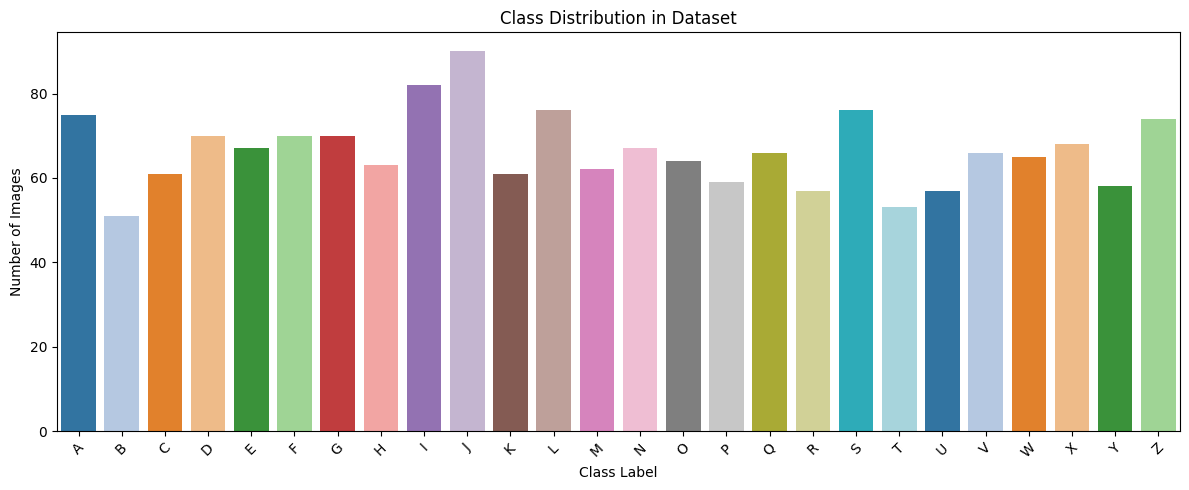

In [128]:
plt.figure(figsize=(12,5))
sns.countplot(
    data=all_df,
    x="label",
    order=sorted(all_df["label"].unique()),
    palette="tab20"
)

plt.title("Class Distribution in Dataset")
plt.xlabel("Class Label")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [129]:
def show_sample_bboxes(df, base_path, n=6):
    sample = df.sample(n=min(n, len(df)), random_state=42)

    plt.figure(figsize=(12, 6))

    for i, (_, row) in enumerate(sample.iterrows(), 1):
        img_path = Path(base_path) / row["image_name"]

        img = cv2.imread(str(img_path))
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        xmin, ymin, xmax, ymax = map(int, [row["xmin"], row["ymin"], row["xmax"], row["ymax"]])
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)

        plt.subplot(2, 3, i)
        plt.imshow(img)
        plt.title(str(row["label"]))
        plt.axis("off")

    plt.tight_layout()
    plt.show()


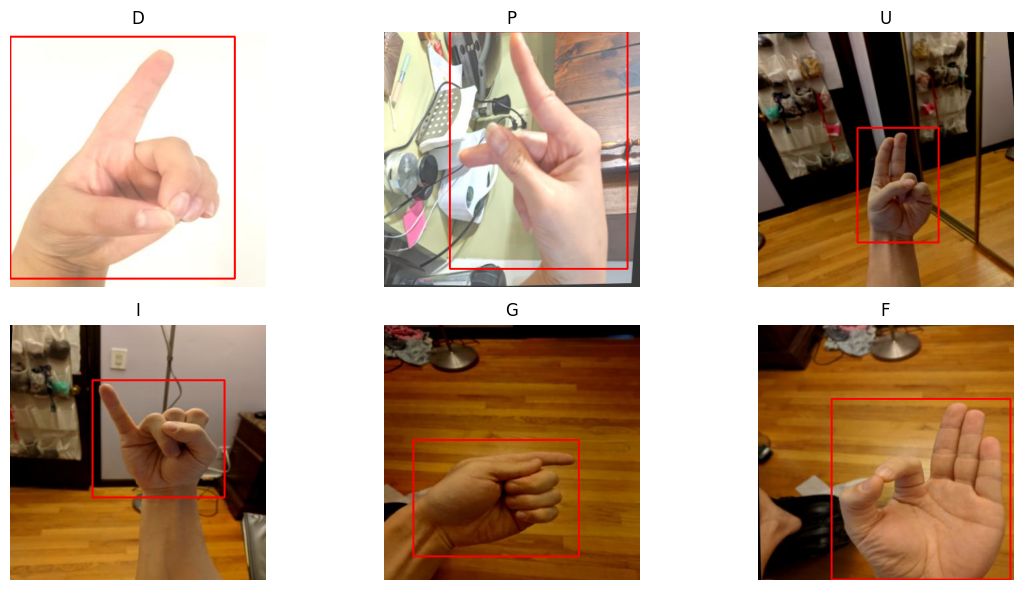

Bounding Box Statistics:
        bbox_width  bbox_height      bbox_area
count  1728.000000  1728.000000    1728.000000
mean    222.599537   210.689815   49349.843171
std      63.518140    69.247957   26294.915067
min      74.000000    59.000000    5550.000000
25%     175.000000   158.000000   30012.000000
50%     217.000000   203.000000   44464.500000
75%     269.000000   257.000000   62766.750000
max     404.000000   414.000000  141804.000000


In [130]:
show_sample_bboxes(train, train_base, n=6)
print("Bounding Box Statistics:")
print(all_df[["bbox_width","bbox_height","bbox_area"]].describe())


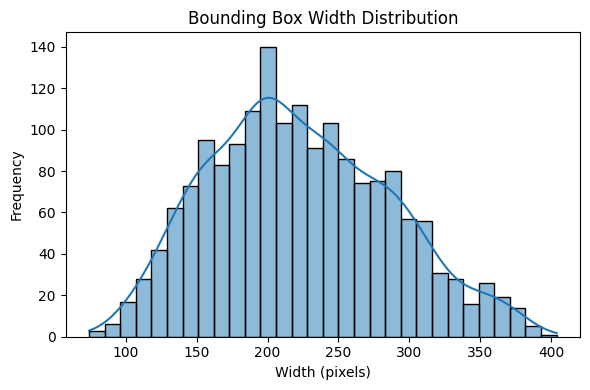

In [131]:
plt.figure(figsize=(6,4))
sns.histplot(all_df["bbox_width"], bins=30, kde=True)
plt.title("Bounding Box Width Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


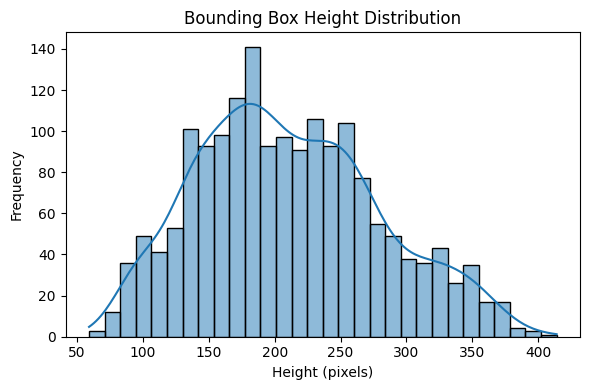

In [132]:
plt.figure(figsize=(6,4))
sns.histplot(all_df["bbox_height"], bins=30, kde=True)
plt.title("Bounding Box Height Distribution")
plt.xlabel("Height (pixels)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


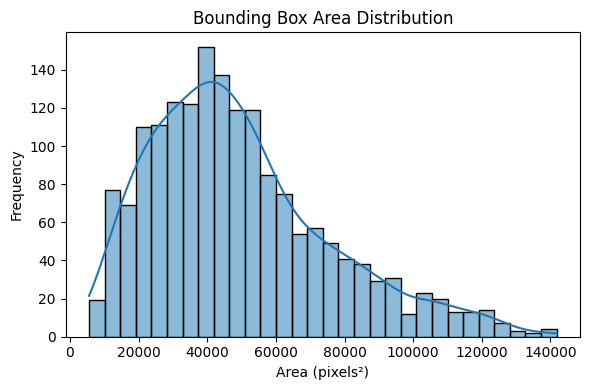

In [133]:
plt.figure(figsize=(6,4))
sns.histplot(all_df["bbox_area"], bins=30, kde=True)
plt.title("Bounding Box Area Distribution")
plt.xlabel("Area (pixels²)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [134]:
# درصد تصاویر در هر اسپلیت
print("Images per split (counts and %):")
print(all_df["split"].value_counts())
print(all_df["split"].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# درصد باکس‌های نامعتبر
invalid_boxes = all_df[(all_df["bbox_width"] <= 0) | (all_df["bbox_height"] <= 0)]
print("\nNumber of invalid bounding boxes:", len(invalid_boxes))
print("Percentage of invalid boxes:", round((len(invalid_boxes) / len(all_df)) * 100, 2), "%")


Images per split (counts and %):
split
train    1512
valid     144
test       72
Name: count, dtype: int64
split
train    87.5%
valid    8.33%
test     4.17%
Name: proportion, dtype: object

Number of invalid bounding boxes: 0
Percentage of invalid boxes: 0.0 %


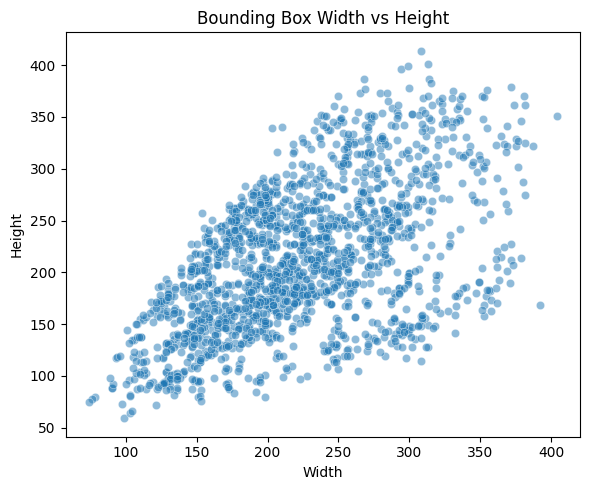

In [135]:

plt.figure(figsize=(6,5))
sns.scatterplot(data=all_df, x="bbox_width", y="bbox_height", alpha=0.5)
plt.title("Bounding Box Width vs Height")
plt.xlabel("Width")
plt.ylabel("Height")
plt.tight_layout()
plt.show()


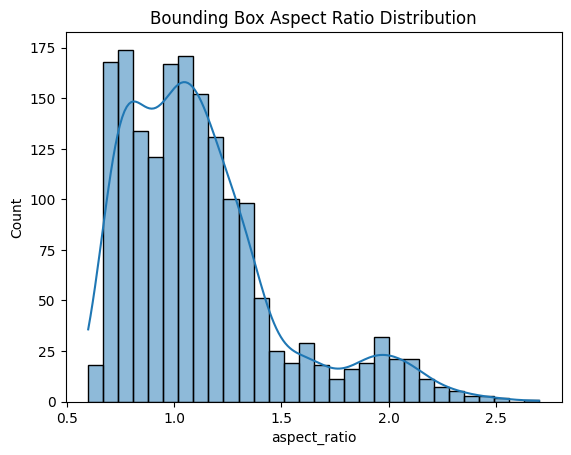

In [136]:
all_df["aspect_ratio"] = all_df["bbox_width"] / all_df["bbox_height"]
sns.histplot(all_df["aspect_ratio"], bins=30, kde=True)
plt.title("Bounding Box Aspect Ratio Distribution")
plt.show()

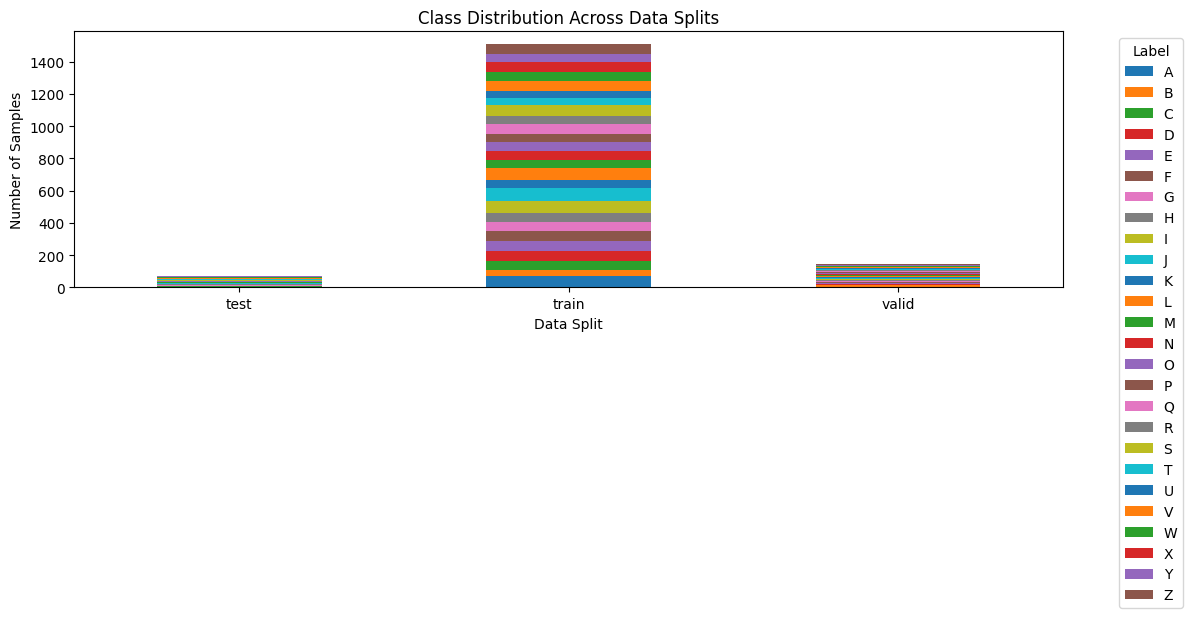

In [137]:
ax = pd.crosstab(all_df["split"], all_df["label"]).plot(kind='bar', stacked=True, figsize=(12,5))
plt.title("Class Distribution Across Data Splits")
plt.xlabel("Data Split")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [138]:
import numpy as np
import pandas as pd

ct = pd.crosstab(all_df["split"], all_df["label"])

summary = pd.DataFrame({
    "min": ct.min(axis=1),
    "max": ct.max(axis=1),
    "mean": ct.mean(axis=1),
    "std": ct.std(axis=1),
})
summary["imbalance_ratio(max/min)"] = (summary["max"] / summary["min"]).replace([np.inf], np.nan)

print("=== Split-wise class balance summary ===")
print(summary.sort_index())

print("\n=== Most underrepresented classes per split (bottom 5) ===")
for sp in ct.index:
    print(f"\n[{sp}]")
    print(ct.loc[sp].sort_values().head(5))


=== Split-wise class balance summary ===
       min  max       mean        std  imbalance_ratio(max/min)
split                                                          
test     0    5   2.769231   1.450729                       NaN
train   39   78  58.153846  10.078461                       2.0
valid    1    9   5.538462   2.176801                       9.0

=== Most underrepresented classes per split (bottom 5) ===

[test]
label
E    0
L    0
D    1
A    1
P    1
Name: test, dtype: int64

[train]
label
B    39
T    42
R    48
U    48
Y    48
Name: train, dtype: int64

[valid]
label
X    1
I    2
W    3
C    3
N    4
Name: valid, dtype: int64


#  Data Preprocessing


All images are cropped using the provided bounding boxes, resized to 128×128 with padding to preserve aspect ratio, and normalized to the [0,1] range.


In [ ]:
def crop_hand_images(df, base_folder):
    base_path = Path(base_folder)
    df = df.sort_values(["label", "image_name"]).reset_index(drop=True) 

    cropped_path = base_path / "cropped"
    cropped_path.mkdir(exist_ok=True) 

    print(f"Starting cropping for: {base_path.name}")
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Cropping {base_path.name}"):
        img_path = base_path / row["image_name"]
        if not img_path.exists():
            
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            
            continue

        h, w = img.shape[:2]

        
        xmin = max(0, int(row["xmin"]))
        ymin = max(0, int(row["ymin"]))
        xmax = min(w, int(row["xmax"]))
        ymax = min(h, int(row["ymax"]))

        
        if xmax <= xmin or ymax <= ymin:
            
            continue

        crop = img[ymin:ymax, xmin:xmax]

        label_folder = cropped_path / str(row["label"])
        label_folder.mkdir(exist_ok=True)

        
        out_path = label_folder / (Path(row["image_name"]).stem + Path(img_path.name).suffix)

        cv2.imwrite(str(out_path), crop)

    print(f"Cropping finished for {base_path.name}")


In [145]:
print("\n--- Cropping Images ---")
crop_hand_images(train, train_base)
crop_hand_images(valid, valid_base)
crop_hand_images(test, test_base)


--- Cropping Images ---
Starting cropping for: train


Cropping train: 100%|██████████| 1512/1512 [00:16<00:00, 89.63it/s]


Cropping finished for train
Starting cropping for: valid


Cropping valid: 100%|██████████| 144/144 [00:01<00:00, 81.35it/s]


Cropping finished for valid
Starting cropping for: test


Cropping test: 100%|██████████| 72/72 [00:00<00:00, 88.09it/s]

Cropping finished for test


In [ ]:
def resize_with_padding(img, target_size, pad_color=(0, 0, 0)):

    if isinstance(target_size, int):
        target_w, target_h = target_size, target_size
    else:
        target_w, target_h = target_size

    h, w = img.shape[:2]
    if h == 0 or w == 0:
        return None

    
    scale = min(target_w / w, target_h / h)
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    
    interp = cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC 
    resized = cv2.resize(img, (new_w, new_h), interpolation=interp)

    
    canvas = np.full((target_h, target_w, 3), pad_color, dtype=np.uint8)
    x0 = (target_w - new_w) // 2
    y0 = (target_h - new_h) // 2
    canvas[y0:y0+new_h, x0:x0+new_w] = resized

    return canvas

In [ ]:
def resize_images_in_folder(base_folder, sizes=(64, 128, 224), pad_color=(0,0,0)):
    base_path = Path(base_folder)
    cropped_path = base_path / "cropped" 

    if not cropped_path.exists():
        print(f"Warning: Cropped images not found at {cropped_path}. Please run cropping first.")
        return

    for size in sizes:
        print(f"\n--- Resizing to {size}x{size} ---")
        resized_path = base_path / f"resized_{size}"
        resized_path.mkdir(exist_ok=True) 

        #
        for label_folder in sorted(cropped_path.iterdir()):
            if not label_folder.is_dir():
                continue

            out_label_folder = resized_path / label_folder.name 
            out_label_folder.mkdir(exist_ok=True)

            
            image_files = sorted(label_folder.glob("*"))
            for img_path in tqdm(image_files, desc=f"Resizing {label_folder.name} to {size}x{size}"):
                img = cv2.imread(str(img_path))
                if img is None:
                    
                    continue

                resized = resize_with_padding(img, target_size=size, pad_color=pad_color)
                if resized is None:
                    
                    continue

                
                out_path = out_label_folder / img_path.name
                cv2.imwrite(str(out_path), resized)

        print(f"Resizing to {size}x{size} finished for {base_path.name}")

print("\n--- Resizing Images ---")


--- Resizing Images ---


In [148]:
resize_images_in_folder(train_base, sizes=(64, 128, 224), pad_color=(0,0,0))
resize_images_in_folder(valid_base, sizes=(64, 128, 224), pad_color=(0,0,0))
resize_images_in_folder(test_base,  sizes=(64, 128, 224), pad_color=(0,0,0))


--- Resizing to 64x64 ---


Resizing Z to 64x64: 100%|██████████| 66/66 [00:00<00:00, 152.17it/s]


Resizing to 64x64 finished for train

--- Resizing to 128x128 ---


Resizing Z to 128x128: 100%|██████████| 66/66 [00:00<00:00, 579.89it/s]


Resizing to 128x128 finished for train

--- Resizing to 224x224 ---


...

Resizing to 64x64 finished for test

--- Resizing to 128x128 ---


Resizing Z to 128x128: 100%|██████████| 4/4 [00:00<00:00, 437.16it/s]


Resizing to 128x128 finished for test

--- Resizing to 224x224 ---


Resizing Z to 224x224: 100%|██████████| 4/4 [00:00<00:00, 417.71it/s]

Resizing to 224x224 finished for test



--- Sample Images after Resizing ---


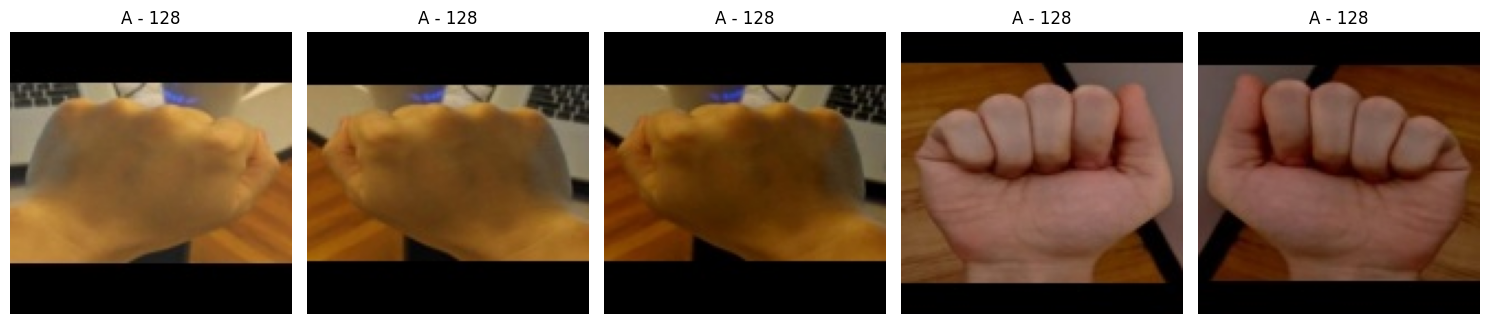

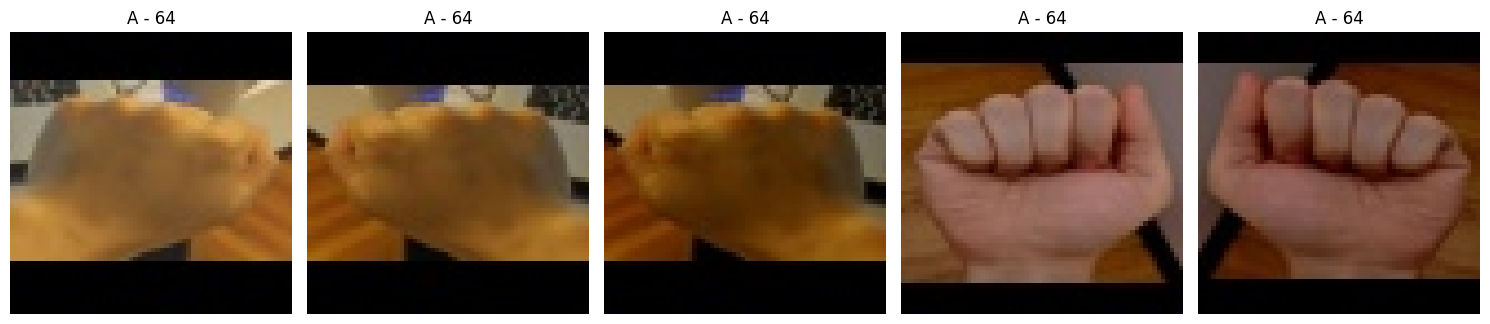

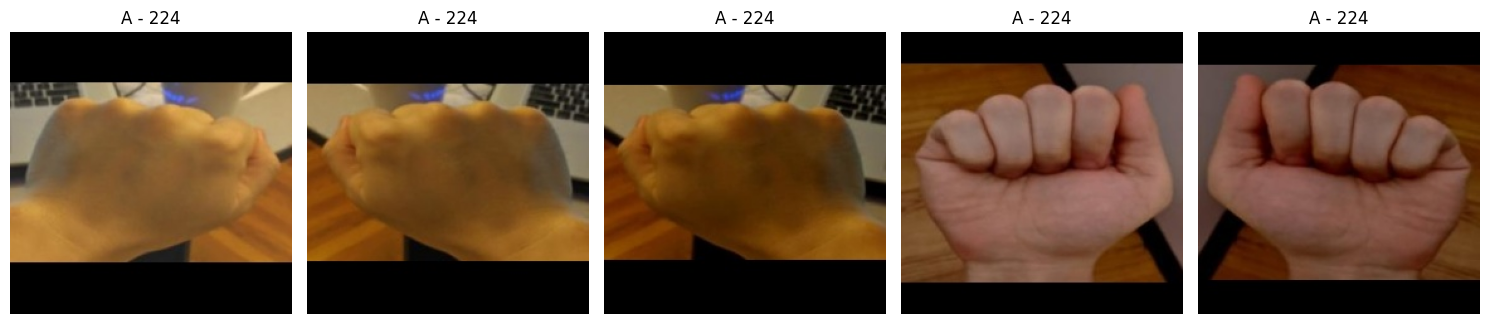

In [ ]:
def show_samples_after_resize(base_folder, size=128, n=5):
    base_path = Path(base_folder)
    resized_path = base_path / f"resized_{size}"

    if not resized_path.exists():
        print(f"Error: Resized path not found: {resized_path}")
        return

    labels = sorted([p for p in resized_path.iterdir() if p.is_dir()])
    if not labels:
        print(f"No label folders found in {resized_path}.")
        return

    samples = []
    for label_folder in labels:
        imgs = sorted(label_folder.glob("*"))
        for img_path in imgs:
            samples.append((label_folder.name, img_path))
            if len(samples) == n: 
                break
        if len(samples) == n:
            break

    if not samples:
        print("No sample images found to display.")
        return

    plt.figure(figsize=(15, 4))
    for i, (label, img_path) in enumerate(samples, 1):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, n, i)
        plt.imshow(img)
        plt.title(f"{label} - {size}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

print("\n--- Sample Images after Resizing ---")
show_samples_after_resize(train_base, size=128, n=5)
show_samples_after_resize(train_base, size=64, n=5)
show_samples_after_resize(train_base, size=224, n=5)

In [ ]:
def normalize_and_save_npy(base_folder, size=128):
    base_path = Path(base_folder)
    resized_path = base_path / f"resized_{size}"
    norm_path = base_path / f"normalized_{size}" # نام پوشه خروجی
    norm_path.mkdir(exist_ok=True)

    print(f"\n--- Normalizing and saving {size}x{size} images to .npy ---")
    for label_folder in sorted(resized_path.iterdir()):
        if not label_folder.is_dir():
            continue

        out_label_folder = norm_path / label_folder.name # پوشه کلاس در normalized_size
        out_label_folder.mkdir(exist_ok=True)

        image_files = sorted(label_folder.glob("*"))
        for img_path in tqdm(image_files, desc=f"Normalizing {label_folder.name}"):
            img = cv2.imread(str(img_path))
            if img is None:
                continue

            
            img_float = img.astype("float32") / 255.0

            
            out_file = out_label_folder / (img_path.stem + ".npy")
            np.save(str(out_file), img_float)

    print(f" Normalized {size}x{size} images saved successfully to {norm_path}")

print("\n--- Normalizing and Saving to .npy ---")
normalize_and_save_npy(train_base, size=128)
normalize_and_save_npy(valid_base, size=128)
normalize_and_save_npy(test_base,  size=128)


--- Normalizing and Saving to .npy ---

--- Normalizing and saving 128x128 images to .npy ---


Normalizing Z: 100%|██████████| 66/66 [00:00<00:00, 109.00it/s]


✅ Normalized 128x128 images saved successfully to data/SignLanguageData/train/normalized_128

--- Normalizing and saving 128x128 images to .npy ---


Normalizing Z: 100%|██████████| 4/4 [00:00<00:00, 82.48it/s]


✅ Normalized 128x128 images saved successfully to data/SignLanguageData/valid/normalized_128

--- Normalizing and saving 128x128 images to .npy ---


Normalizing Z: 100%|██████████| 4/4 [00:00<00:00, 75.35it/s]

✅ Normalized 128x128 images saved successfully to data/SignLanguageData/test/normalized_128


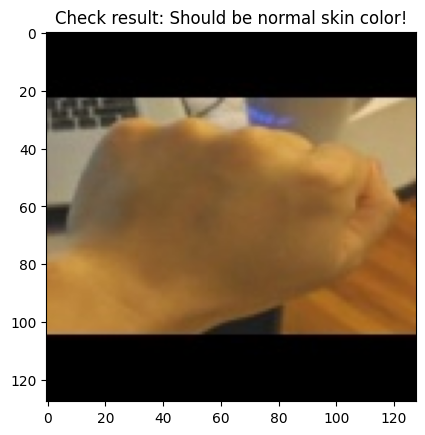

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def check_normalized_file(npy_path):
    img = np.load(npy_path)
    
    img_rgb = cv2.cvtColor((img * 255).astype('uint8'), cv2.COLOR_BGR2RGB)
    
    plt.imshow(img_rgb)
    plt.title("Check result: Should be normal skin color!")
    plt.show()

sample_npy = next(Path(train_base, "normalized_128", "A").glob("*.npy"))
check_normalized_file(str(sample_npy))
#ok

#  Clustering Analysis and Model Evaluation and Comparative Analysis


- Model Training
We train a CNN-based classifier with early stopping and model checkpointing based on validation accuracy.
- Evaluation
The final model is evaluated using accuracy, macro/weighted precision, recall, F1-score, and confusion matrix analysis.


In [ ]:
import cv2
import numpy as np
from pathlib import Path
#128
def load_dataset(base_folder):
    base_path = Path(base_folder)
    data_path = base_path / "normalized_128"
    X, y = [], []

    for label_folder in sorted(data_path.iterdir()):
        if not label_folder.is_dir(): continue
        label = label_folder.name
        
        for npy_file in label_folder.glob("*.npy"):
            img = np.load(npy_file)
            

            if img.dtype != np.uint8:
                img = (img * 255).astype(np.uint8)
            
            
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            X.append(img_rgb.astype('float32') / 255.0)
            y.append(label)

    return np.array(X), np.array(y)

X_train, y_train = load_dataset(train_base)
X_valid, y_valid = load_dataset(valid_base)
X_test, y_test   = load_dataset(test_base)


X_train, y_train = shuffle(X_train, y_train, random_state=42)

le = LabelEncoder()

all_labels = np.concatenate([y_train,y_test,y_valid])
le.fit(all_labels)

y_train = le.transform(y_train)
y_valid = le.transform(y_valid)
y_test  = le.transform(y_test)

num_classes = len(le.classes_)

In [161]:
print("Number of classes:", num_classes)
print("Classes:", le.classes_)
print("Train shape:", X_train.shape)
print("Valid shape:", X_valid.shape)
print("Test shape:", X_test.shape)


Number of classes: 26
Classes: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
Train shape: (1512, 128, 128, 3)
Valid shape: (144, 128, 128, 3)
Test shape: (72, 128, 128, 3)


In [ ]:

num_classes = len(le.classes_)
print(f"Correct num_classes: {num_classes}")


Correct num_classes: 26


In [164]:
print("Min label:", np.min(y_train))
print("Max label:", np.max(y_train))


Min label: 0
Max label: 25


In [165]:
print(f"X_train range: {X_train.min()} to {X_train.max()}")
print(f"X_valid range: {X_valid.min()} to {X_valid.max()}")


X_train range: 0.0 to 1.0
X_valid range: 0.0 to 1.0


In [ ]:


gc.collect()
tf.keras.backend.clear_session()

EFF_WEIGHTS = WEIGHTS_DIR / "efficientnetb0_notop.h5"
print("local EfficientNetB0 weights found:", EFF_WEIGHTS.exists())

X_train_eff = eff_input(X_train.copy() * 255.0)
X_valid_eff = eff_input(X_valid.copy() * 255.0)
X_test_eff  = eff_input(X_test.copy() * 255.0)

data_augmentation = models.Sequential([
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2)
], name="data_augmentation")

if EFF_WEIGHTS.exists():
    base_model_eff = EfficientNetB0(input_shape=(128, 128, 3), include_top=False, weights=None)
    base_model_eff.load_weights(str(EFF_WEIGHTS))
else:  # download the same ImageNet weights automatically
    base_model_eff = EfficientNetB0(input_shape=(128, 128, 3), include_top=False, weights="imagenet")

base_model_eff.trainable = False

inputs = tf.keras.Input(shape=(128, 128, 3))
x = data_augmentation(inputs)
x = base_model_eff(x, training=False)  
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(
    num_classes,
    activation='softmax',
    kernel_regularizer=l2(1e-4)
)(x)

model_eff = tf.keras.Model(inputs, outputs)

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_stage1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "efficientnet_stage1_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

history_stage1_e = model_eff.fit(
    X_train_eff, y_train,
    validation_data=(X_valid_eff, y_valid),
    epochs=50,
    batch_size=32,
    callbacks=callbacks_stage1
)

True
Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.0704 - loss: 3.3260
Epoch 1: val_accuracy improved from None to 0.13889, saving model to efficientnet_stage1_best.keras

Epoch 1: finished saving model to efficientnet_stage1_best.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 38s 544ms/step - accuracy: 0.1071 - loss: 3.1813 - val_accuracy: 0.1389 - val_loss: 2.9365 - learning_rate: 0.0010
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.2229 - loss: 2.7324
Epoch 2: val_accuracy improved from 0.13889 to 0.27083, saving model to efficientnet_stage1_best.keras

Epoch 2: finished saving model to efficientnet_stage1_best.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 25s 514ms/step - accuracy: 0.2520 - loss: 2.6514 - val_accuracy: 0.2708 - val_loss: 2.5608 - learning_rate: 0.0010
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.3471 - loss: 2.3432
Epoch 3: val_accuracy improved from 0.27083 to 0.38889, saving model to efficientnet_stage1_best.keras

Epoch 3: finis

In [170]:
base_model_eff.trainable = True

fine_tune_at = len(base_model_eff.layers) - 30
for layer in base_model_eff.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model_eff.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model_eff.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_stage2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "efficientnet_stage2_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

history_stage2_e = model_eff.fit(
    X_train_eff, y_train,
    validation_data=(X_valid_eff, y_valid),
    epochs=50,
    batch_size=32,
    callbacks=callbacks_stage2
)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.6767 - loss: 1.0922
Epoch 1: val_accuracy improved from None to 0.60417, saving model to efficientnet_stage2_best.keras

Epoch 1: finished saving model to efficientnet_stage2_best.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 39s 512ms/step - accuracy: 0.6825 - loss: 1.0841 - val_accuracy: 0.6042 - val_loss: 1.2324 - learning_rate: 1.0000e-05
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.7024 - loss: 1.0341
Epoch 2: val_accuracy did not improve from 0.60417
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 431ms/step - accuracy: 0.7037 - loss: 1.0016 - val_accuracy: 0.5972 - val_loss: 1.2017 - learning_rate: 1.0000e-05
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.6994 - loss: 1.0327
Epoch 3: val_accuracy did not improve from 0.60417
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 433ms/step - accuracy: 0.7070 - loss: 0.9935 - val_accuracy: 0.5972 - val_loss: 1.1883 - learning_rate: 1.0000e-05
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━

In [ ]:
def final_report(history, model_name="Model"):
    import numpy as np

    train_acc  = history.history['accuracy']
    val_acc    = history.history['val_accuracy']
    train_loss = history.history['loss']
    val_loss   = history.history['val_loss']

    best_epoch_idx = np.argmax(val_acc)

    print(f"\n========== {model_name} Final Report ==========")
    print(f"Best Epoch (Saved by Val Accuracy): {best_epoch_idx + 1}")

    print("\n--- Metrics at Best Saved Model Epoch ---")
    print(f"Train Accuracy : {train_acc[best_epoch_idx]:.4f}")
    print(f"Valid Accuracy : {val_acc[best_epoch_idx]:.4f}")
    print(f"Train Loss     : {train_loss[best_epoch_idx]:.4f}")
    print(f"Valid Loss     : {val_loss[best_epoch_idx]:.4f}")

    print("\n--- Absolute Peaks in History ---")
    print(f"Absolute Max Train Accuracy : {max(train_acc):.4f} (at Epoch {np.argmax(train_acc) + 1})")
    print(f"Absolute Max Valid Accuracy : {max(val_acc):.4f} (at Epoch {np.argmax(val_acc) + 1})")
    print(f"Absolute Min Train Loss     : {min(train_loss):.4f} (at Epoch {np.argmin(train_loss) + 1})")
    print(f"Absolute Min Valid Loss     : {min(val_loss):.4f} (at Epoch {np.argmin(val_loss) + 1})")
    
    print("\n--- Last Epoch of Training (Before stopping) ---")
    print(f"Final Train Accuracy : {train_acc[-1]:.4f}")
    print(f"Final Valid Accuracy : {val_acc[-1]:.4f}")
    print(f"Final Train Loss     : {train_loss[-1]:.4f}")
    print(f"Final Valid Loss     : {val_loss[-1]:.4f}")
    print("=========================================")


In [172]:
final_report(history_stage1_e, "efficientnet")



========== efficientnet Final Report ==========
Best Epoch (Saved by Val Accuracy): 29

--- Metrics at Best Saved Model Epoch ---
Train Accuracy : 0.6918
Valid Accuracy : 0.5972
Train Loss     : 1.0897
Valid Loss     : 1.3225

--- Absolute Peaks in History ---
Absolute Max Train Accuracy : 0.7116 (at Epoch 45)
Absolute Max Valid Accuracy : 0.5972 (at Epoch 29)
Absolute Min Train Loss     : 1.0479 (at Epoch 49)
Absolute Min Valid Loss     : 1.2969 (at Epoch 44)

--- Last Epoch of Training (Before stopping) ---
Final Train Accuracy : 0.7017
Final Valid Accuracy : 0.5972
Final Train Loss     : 1.0479
Final Valid Loss     : 1.2995


In [173]:
final_report(history_stage2_e, "efficientnet")



========== efficientnet Final Report ==========
Best Epoch (Saved by Val Accuracy): 35

--- Metrics at Best Saved Model Epoch ---
Train Accuracy : 0.7890
Valid Accuracy : 0.7153
Train Loss     : 0.6913
Valid Loss     : 0.9432

--- Absolute Peaks in History ---
Absolute Max Train Accuracy : 0.8049 (at Epoch 41)
Absolute Max Valid Accuracy : 0.7153 (at Epoch 35)
Absolute Min Train Loss     : 0.6543 (at Epoch 45)
Absolute Min Valid Loss     : 0.9389 (at Epoch 44)

--- Last Epoch of Training (Before stopping) ---
Final Train Accuracy : 0.8029
Final Valid Accuracy : 0.7014
Final Train Loss     : 0.6621
Final Valid Loss     : 0.9394


In [ ]:


def evaluate_model(model, name, X_data, y_true, le):
    test_loss, test_acc = model.evaluate(X_data, y_true, verbose=0)
    print(f"\n{name} Test Loss: {test_loss:.4f}")
    print(f"{name} Test Accuracy: {test_acc:.4f}")

    y_pred_prob = model.predict(X_data, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    print("\nClassification Report:")
    present_labels = np.unique(y_true)

    print(classification_report(
    y_true,
    y_pred,
    labels=present_labels,
    target_names=le.classes_[present_labels],
    zero_division=0
))
    present_labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=present_labels)

    sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=le.classes_[present_labels],
    yticklabels=le.classes_[present_labels],
    cmap='Blues'
)


    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()



eff Test Loss: 1.2059
eff Test Accuracy: 0.6250

Classification Report:
              precision    recall  f1-score   support

           A       0.20      1.00      0.33         1
           B       1.00      1.00      1.00         3
           C       0.67      0.50      0.57         4
           D       0.25      1.00      0.40         1
           F       0.00      0.00      0.00         2
           G       0.57      0.80      0.67         5
           H       1.00      0.33      0.50         3
           I       0.50      0.50      0.50         2
           J       1.00      0.50      0.67         4
           K       0.50      0.25      0.33         4
           M       0.00      0.00      0.00         3
           N       0.25      0.33      0.29         3
           O       0.75      1.00      0.86         3
           P       0.33      1.00      0.50         1
           Q       1.00      0.50      0.67         2
           R       1.00      0.50      0.67         2
        

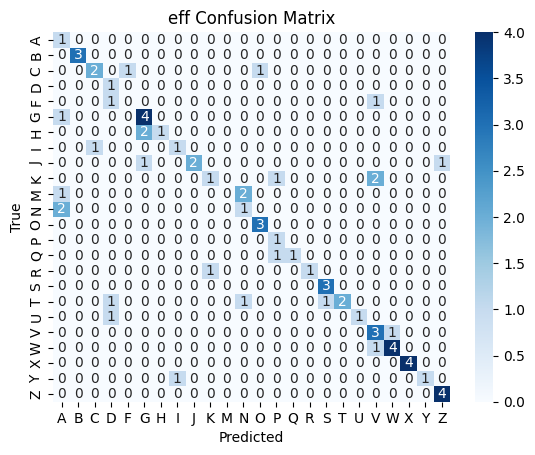

In [181]:
evaluate_model(model_eff, "eff", X_test_eff, y_test, le)


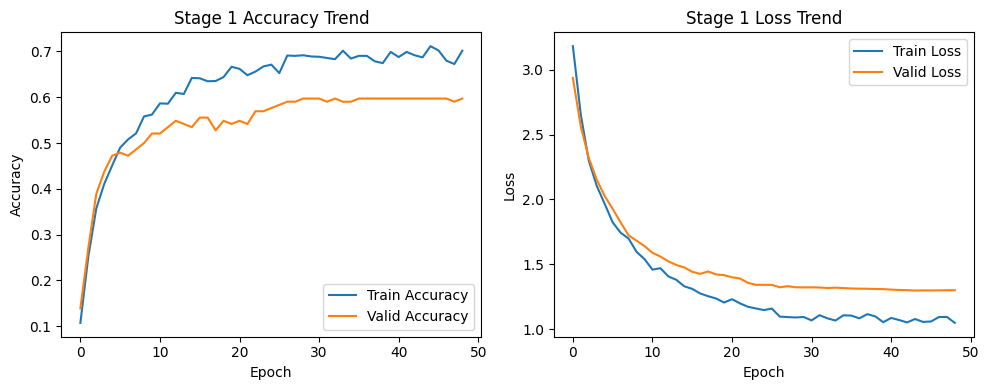

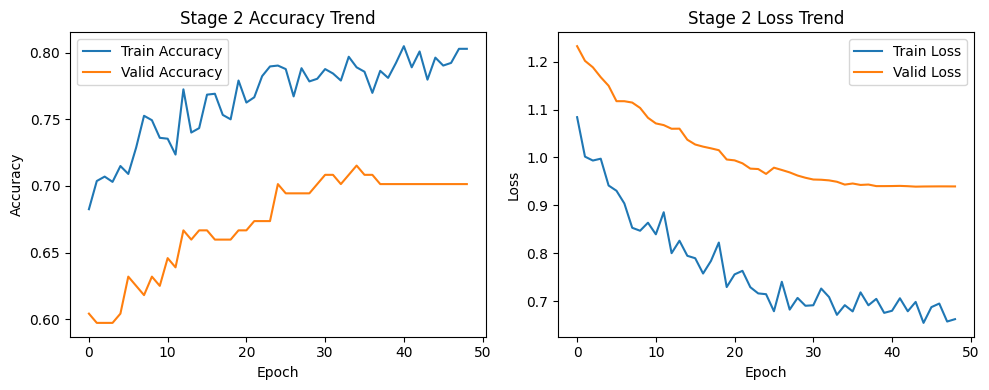

In [183]:
import matplotlib.pyplot as plt

def plot_history(history, title_prefix="Stage"):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Valid Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f'{title_prefix} Accuracy Trend')

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Valid Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'{title_prefix} Loss Trend')

    plt.tight_layout()
    plt.show()

# Stage 1
plot_history(history_stage1_e, "Stage 1")

# Stage 2
plot_history(history_stage2_e, "Stage 2")


In [ ]:


gc.collect()
tf.keras.backend.clear_session()

# preprocess
X_train_mob = mobile_input(X_train.copy() * 255.0)
X_valid_mob = mobile_input(X_valid.copy() * 255.0)
X_test_mob  = mobile_input(X_test.copy() * 255.0)

# augmentation ملایم
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.1),      
    layers.RandomZoom(0.1),          
    layers.RandomTranslation(0.05, 0.05), 
], name="augmentation")

# base model
MOB_WEIGHTS = WEIGHTS_DIR / "mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_128_no_top.h5"
if MOB_WEIGHTS.exists():
    base_model3 = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights=None)
    base_model3.load_weights(str(MOB_WEIGHTS))
else:  # download the same ImageNet weights automatically
    base_model3 = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights="imagenet")


base_model3.trainable = False

inputs = tf.keras.Input(shape=(128, 128, 3))
x = data_augmentation(inputs)
x = base_model3(x, training=False)   # خیلی مهم
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax', kernel_regularizer=l2(1e-4))(x)
model_mob = tf.keras.Model(inputs, outputs)

model_mob.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
callbacks_stage1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "mobilenet_stage1_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]


history_stage1 = model_mob.fit(
    X_train_mob, y_train,
    validation_data=(X_valid_mob, y_valid),
    epochs=50,
    batch_size=32,
    callbacks=callbacks_stage1
)


Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.0893 - loss: 3.8109
Epoch 1: val_accuracy improved from None to 0.29861, saving model to mobilenet_stage1_best.keras

Epoch 1: finished saving model to mobilenet_stage1_best.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 351ms/step - accuracy: 0.1329 - loss: 3.4121 - val_accuracy: 0.2986 - val_loss: 2.2921 - learning_rate: 0.0010
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.2525 - loss: 2.5246
Epoch 2: val_accuracy improved from 0.29861 to 0.50000, saving model to mobilenet_stage1_best.keras

Epoch 2: finished saving model to mobilenet_stage1_best.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 354ms/step - accuracy: 0.3049 - loss: 2.3945 - val_accuracy: 0.5000 - val_loss: 1.7421 - learning_rate: 0.0010
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.4142 - loss: 1.9698
Epoch 3: val_accuracy improved from 0.50000 to 0.56250, saving model to mobilenet_stage1_best.keras

Epoch 3: finished saving model to 

In [ ]:
base_model3.trainable = True

fine_tune_at = len(base_model3.layers) - 30

for layer in base_model3.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model3.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model_mob.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_stage2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "mobilenet_stage2_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]


history_stage2 = model_mob.fit(
    X_train_mob, y_train,
    validation_data=(X_valid_mob, y_valid),
    epochs=50,
    batch_size=32,
    callbacks=callbacks_stage2
)


Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.8377 - loss: 0.5402
Epoch 1: val_accuracy improved from None to 0.74306, saving model to mobilenet_stage2_best.keras

Epoch 1: finished saving model to mobilenet_stage2_best.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 24s 361ms/step - accuracy: 0.8313 - loss: 0.5374 - val_accuracy: 0.7431 - val_loss: 1.0162 - learning_rate: 1.0000e-05
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.8675 - loss: 0.4529
Epoch 2: val_accuracy improved from 0.74306 to 0.75694, saving model to mobilenet_stage2_best.keras

Epoch 2: finished saving model to mobilenet_stage2_best.keras
48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 335ms/step - accuracy: 0.8552 - loss: 0.4587 - val_accuracy: 0.7569 - val_loss: 0.9241 - learning_rate: 1.0000e-05
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.8454 - loss: 0.4565
Epoch 3: val_accuracy improved from 0.75694 to 0.77083, saving model to mobilenet_stage2_best.keras

Epoch 3: finished saving m

In [ ]:
def final_report(history, model_name="Model"):
    import numpy as np

    train_acc  = history.history['accuracy']
    val_acc    = history.history['val_accuracy']
    train_loss = history.history['loss']
    val_loss   = history.history['val_loss']

    best_epoch_idx = np.argmax(val_acc)

    print(f"\n========== {model_name} Final Report ==========")
    print(f"Best Epoch (Saved by Val Accuracy): {best_epoch_idx + 1}")

    print("\n--- Metrics at Best Saved Model Epoch ---")
    print(f"Train Accuracy : {train_acc[best_epoch_idx]:.4f}")
    print(f"Valid Accuracy : {val_acc[best_epoch_idx]:.4f}")
    print(f"Train Loss     : {train_loss[best_epoch_idx]:.4f}")
    print(f"Valid Loss     : {val_loss[best_epoch_idx]:.4f}")

    print("\n--- Absolute Peaks in History ---")
    print(f"Absolute Max Train Accuracy : {max(train_acc):.4f} (at Epoch {np.argmax(train_acc) + 1})")
    print(f"Absolute Max Valid Accuracy : {max(val_acc):.4f} (at Epoch {np.argmax(val_acc) + 1})")
    print(f"Absolute Min Train Loss     : {min(train_loss):.4f} (at Epoch {np.argmin(train_loss) + 1})")
    print(f"Absolute Min Valid Loss     : {min(val_loss):.4f} (at Epoch {np.argmin(val_loss) + 1})")
    
    print("\n--- Last Epoch of Training (Before stopping) ---")
    print(f"Final Train Accuracy : {train_acc[-1]:.4f}")
    print(f"Final Valid Accuracy : {val_acc[-1]:.4f}")
    print(f"Final Train Loss     : {train_loss[-1]:.4f}")
    print(f"Final Valid Loss     : {val_loss[-1]:.4f}")
    print("=========================================")


In [190]:
final_report(history_stage1, "mobilenet")



========== mobilenet Final Report ==========
Best Epoch (Saved by Val Accuracy): 25

--- Metrics at Best Saved Model Epoch ---
Train Accuracy : 0.8380
Valid Accuracy : 0.7639
Train Loss     : 0.5400
Valid Loss     : 0.9393

--- Absolute Peaks in History ---
Absolute Max Train Accuracy : 0.8433 (at Epoch 24)
Absolute Max Valid Accuracy : 0.7639 (at Epoch 25)
Absolute Min Train Loss     : 0.5393 (at Epoch 27)
Absolute Min Valid Loss     : 0.9383 (at Epoch 22)

--- Last Epoch of Training (Before stopping) ---
Final Train Accuracy : 0.8353
Final Valid Accuracy : 0.7500
Final Train Loss     : 0.5393
Final Valid Loss     : 0.9397


In [191]:
final_report(history_stage2, "mobilenet")



========== mobilenet Final Report ==========
Best Epoch (Saved by Val Accuracy): 3

--- Metrics at Best Saved Model Epoch ---
Train Accuracy : 0.8512
Valid Accuracy : 0.7708
Train Loss     : 0.4473
Valid Loss     : 0.9613

--- Absolute Peaks in History ---
Absolute Max Train Accuracy : 0.8790 (at Epoch 7)
Absolute Max Valid Accuracy : 0.7708 (at Epoch 3)
Absolute Min Train Loss     : 0.3890 (at Epoch 5)
Absolute Min Valid Loss     : 0.9241 (at Epoch 2)

--- Last Epoch of Training (Before stopping) ---
Final Train Accuracy : 0.8790
Final Valid Accuracy : 0.7639
Final Train Loss     : 0.3928
Final Valid Loss     : 0.9451



MobileNetV2_Stage2 Test Loss: 1.3288
MobileNetV2_Stage2 Test Accuracy: 0.6944

Classification Report:
              precision    recall  f1-score   support

           A       0.17      1.00      0.29         1
           B       1.00      1.00      1.00         3
           C       0.67      0.50      0.57         4
           D       1.00      1.00      1.00         1
           F       0.33      0.50      0.40         2
           G       0.83      1.00      0.91         5
           H       1.00      0.67      0.80         3
           I       0.33      0.50      0.40         2
           J       1.00      0.75      0.86         4
           K       0.00      0.00      0.00         4
           M       1.00      0.67      0.80         3
           N       0.50      0.33      0.40         3
           O       1.00      1.00      1.00         3
           P       0.50      1.00      0.67         1
           Q       1.00      0.50      0.67         2
           R       0.50      1.0

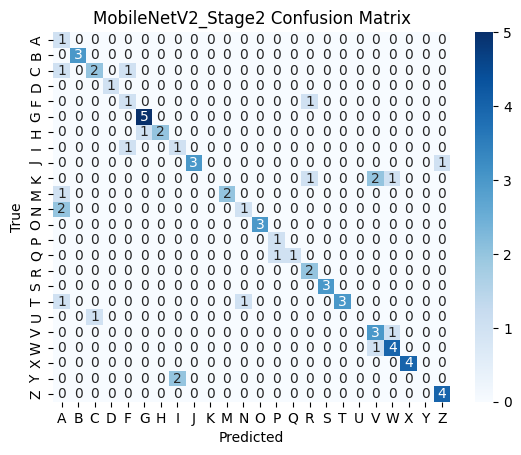

In [193]:
evaluate_model(model_mob, "MobileNetV2_Stage2", X_test_mob, y_test, le)


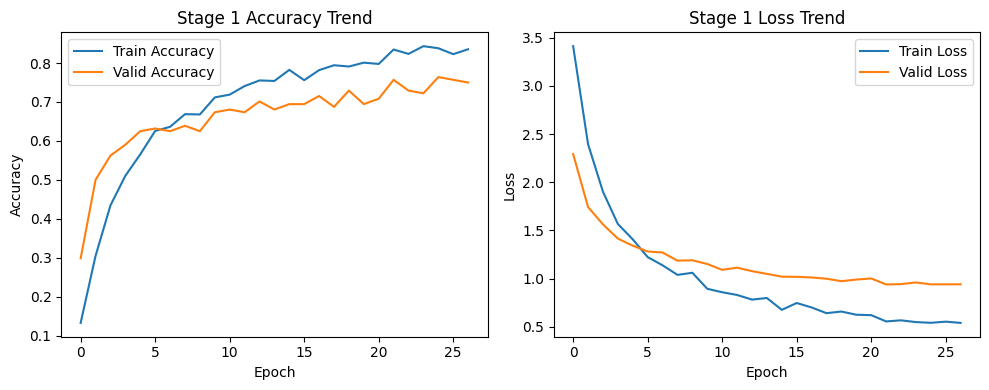

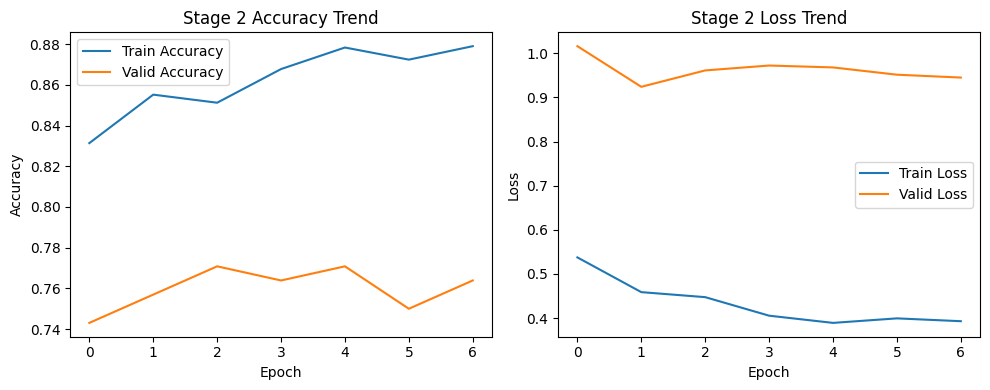

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title_prefix="Stage"):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Valid Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f'{title_prefix} Accuracy Trend')

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Valid Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'{title_prefix} Loss Trend')

    plt.tight_layout()
    plt.show()

plot_history(history_stage1, "Stage 1")

plot_history(history_stage2, "Stage 2")


# Conclusion
Overall, despite the small test set, the data preparation pipeline (cropping the hand region, resizing with padding, and normalization) and the two-stage training strategy (initial training followed by fine-tuning) were appropriate. After fine-tuning, EfficientNetB achieved a reasonably good performance; however, the results indicated that its performance was not uniform across classes and it failed to correctly recognize certain letters (such as F and M). To enable a more reliable evaluation, MobileNetV was also trained, and it showed a substantial improvement during fine-tuning—leading to better generalization and more stable predictions across most classes. The per-class report and the confusion matrix analysis also suggest that MobileNetV performs more strongly on many letters, although a few classes such as K, U, and Y still remain challenging, likely due to gesture similarity, visual ambiguity, or data limitations. Therefore, MobileNetV is selected as the more suitable option for this task.
